# Sweep of `RCP_ALPHA_SCALE`

Effect of the initial learning-rate scale on the final packing fraction for a Weibull size distribution (shape 3, scale 1), N = 1000, same seed for every run.

`RCP_ALPHA_SCALE` multiplies the initial `alpha` (0.0045 in 3D) and `alpha_max`. It is read by the C++ core through `getenv` (accepted range 0 < s < 100, 3D only), so it is set with `os.environ` before each `pack()` call. The 8 points are log-spaced between 0.1 and 10. `alpha_history` is used to check that each value took effect.

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from rcpgenerator import Packing

In [2]:
N = 1000
SEED = 123
N_POINTS = 8

scales = np.logspace(np.log10(0.1), np.log10(10.0), N_POINTS)   # 8 log-spaced points, 0.1 -> 10
print(scales)

[ 0.1         0.19306977  0.37275937  0.71968567  1.38949549  2.6826958
  5.17947468 10.        ]


In [3]:
def run_packing(alpha_scale):
    """Pack from the same seeded initial configuration with a given RCP_ALPHA_SCALE."""
    os.environ["RCP_ALPHA_SCALE"] = repr(float(alpha_scale))
    packing = Packing(
        phi = 0.1,      # Initial particle volume fraction
        N = N,          # Number of particles
        Ndim = 3,       # Number of dimensions
        box = [1.0, 1.0, 1.0],
        walls = [0, 0, 0],   # periodic
        dist = {"type": "weibull", "shape": 3.0, "scale": 1.0},
        neighbor_max = 0,
        seed = SEED,    # same seed -> same initial configuration
    )
    t0 = time.time()
    packing.pack()
    return packing, time.time() - t0

In [4]:
results = []
try:
    for s in scales:
        packing, elapsed = run_packing(s)
        alpha = np.asarray(packing.alpha_history)
        results.append({
            "scale": s,
            "phi_final": packing.phi_final,
            "steps": packing.steps,
            "time": elapsed,
            "alpha_history": alpha,
            "mu_history": np.asarray(packing.mu_history),
        })
        print(f"scale={s:.4f}  phi_final={packing.phi_final:.6f}  steps={packing.steps}  "
              f"time={elapsed:.1f}s  alpha[0]={alpha[0] if len(alpha) else float('nan'):.5f}")
finally:
    os.environ.pop("RCP_ALPHA_SCALE", None)   # leave the environment clean

scale=0.1000  phi_final=0.651077  steps=16366  time=2.0s  alpha[0]=0.00045


scale=0.1931  phi_final=0.654802  steps=16430  time=2.0s  alpha[0]=0.00087
scale=0.3728  phi_final=0.656267  steps=16459  time=2.0s  alpha[0]=0.00168


scale=0.7197  phi_final=0.658062  steps=16375  time=2.1s  alpha[0]=0.00324
scale=1.3895  phi_final=0.660523  steps=16423  time=2.4s  alpha[0]=0.00625


scale=2.6827  phi_final=0.657191  steps=16373  time=2.8s  alpha[0]=0.01207


scale=5.1795  phi_final=0.658651  steps=16385  time=3.2s  alpha[0]=0.02331
scale=10.0000  phi_final=0.656947  steps=16332  time=2.9s  alpha[0]=0.04500


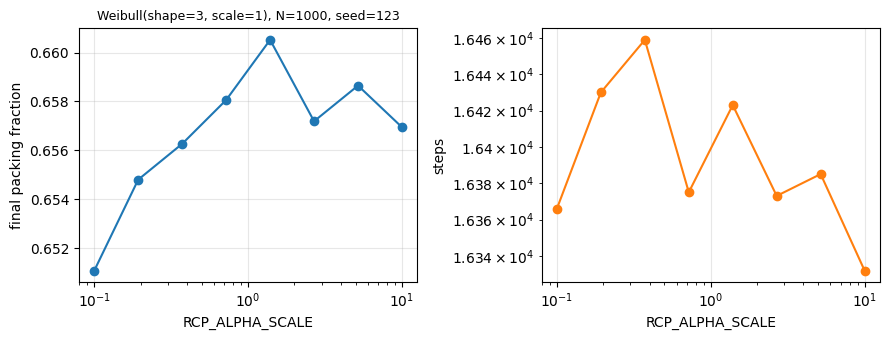

In [5]:
phi_final = np.array([r["phi_final"] for r in results])
steps = np.array([r["steps"] for r in results])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.semilogx(scales, phi_final, "o-")
ax1.set_xlabel("RCP_ALPHA_SCALE")
ax1.set_ylabel("final packing fraction")
ax1.set_title(f"Weibull(shape=3, scale=1), N={N}, seed={SEED}", fontsize=9)
ax1.grid(alpha=0.3)
ax2.loglog(scales, steps, "o-", color="tab:orange")
ax2.set_xlabel("RCP_ALPHA_SCALE")
ax2.set_ylabel("steps")
ax2.grid(alpha=0.3)
fig.tight_layout()
plt.show()

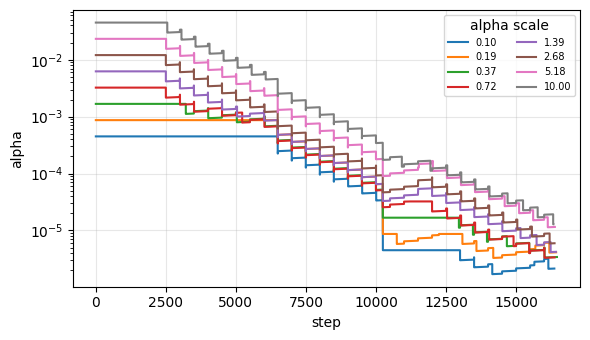

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for r in results:
    ax.semilogy(r["alpha_history"], label=f"{r['scale']:.2f}")
ax.set_xlabel("step")
ax.set_ylabel("alpha")
ax.legend(title="alpha scale", fontsize=7, ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()